<a href="https://colab.research.google.com/github/moneymahajan-oss/atec3-3b853bc3/blob/main/test1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target flower_name  
0       0      setosa  
1       0      setosa  
2       0      setosa  
3       0      setosa  
4       0      setosa  

Dataset shape:
(150, 6)

Column names:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target', 'flower_name'],
      dtype='object')

Basic statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          

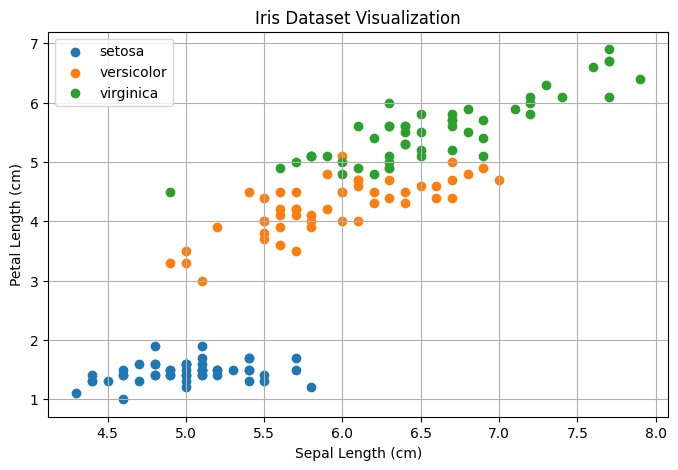


Model Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [1]:
# Simple Data Science Program for Beginners
# Works in Google Colab

# Step 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Step 2: Load dataset
iris = load_iris()

# Step 3: Convert to pandas DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target
df["flower_name"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

# Step 4: Show first rows
print("First 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nBasic statistics:")
print(df.describe())

print("\nClass counts:")
print(df["flower_name"].value_counts())

# Step 5: Simple visualization
plt.figure(figsize=(8, 5))
for flower in df["flower_name"].unique():
    subset = df[df["flower_name"] == flower]
    plt.scatter(
        subset["sepal length (cm)"],
        subset["petal length (cm)"],
        label=flower
    )

plt.title("Iris Dataset Visualization")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.legend()
plt.grid(True)
plt.show()

# Step 6: Prepare data for machine learning
X = df[iris.feature_names]
y = df["target"]

# Step 7: Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 8: Train model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Step 9: Make predictions
y_pred = model.predict(X_test)

# Step 10: Evaluate model
print("\nModel Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))
